# POKEMON

### Analitika kitabxanalarının yüklənməsi və Datasetin Gətirilməsi

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df =pd.read_excel(r'C:\Users\Lenova\Desktop\MDA39\layiheler\python layihe\Pokemon\Pokemon.xlsx')

In [5]:
df.head(5)

,#,name,type1,type2,base_total,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,is_legendary,generation,capture_rate,base_happiness,percentage_male
0,1,Bulbasaur,grass,poison,318,45,49,49,65,65,45,0.7,6.9,0,1,45,70,88.1
1,2,Ivysaur,grass,poison,405,60,62,63,80,80,60,1.0,13.0,0,1,45,70,88.1
2,3,Venusaur,grass,poison,625,80,100,123,122,120,80,2.0,100.0,0,1,45,70,88.1
3,4,Charmander,fire,NaN,309,39,52,43,60,50,65,0.6,8.5,0,1,45,70,88.1
4,5,Charmeleon,fire,NaN,405,58,64,58,80,65,80,1.1,19.0,0,1,45,70,88.1


#### Datasetdə ən çox yayılmış Pokemon növü hansıdır? Bu tip nə qədər Pokemon var?

In [6]:
df['type1'].value_counts().head(1)

type1
water    114
Name: count, dtype: int64

#### Digər növləri ilə müqayisədə həddindən artıq yüksək və ya aşağı statistikaya malik hər hansı Pokemon varmı?

In [40]:
mean = df['base_total'].mean()
std = df['base_total'].std()

lower = mean - 2*std
upper = mean + 2*std
outlier = df[(df['base_total'] > upper) | (df['base_total'] < lower)]

outlier[['name','base_total']]

,name,base_total
149,Mewtwo,780
190,Sunkern,180
247,Tyranitar,700
248,Lugia,680
249,Ho-Oh,680
288,Slaking,670
372,Salamence,700
375,Metagross,700
379,Latias,700
380,Latios,700


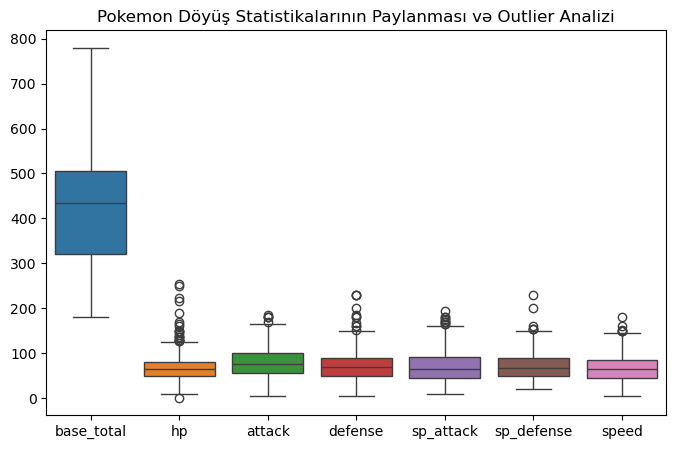

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['base_total','hp','attack','defense','sp_attack','sp_defense','speed']])
plt.title('Pokemon Döyüş Statistikalarının Paylanması və Outlier Analizi')
plt.show()

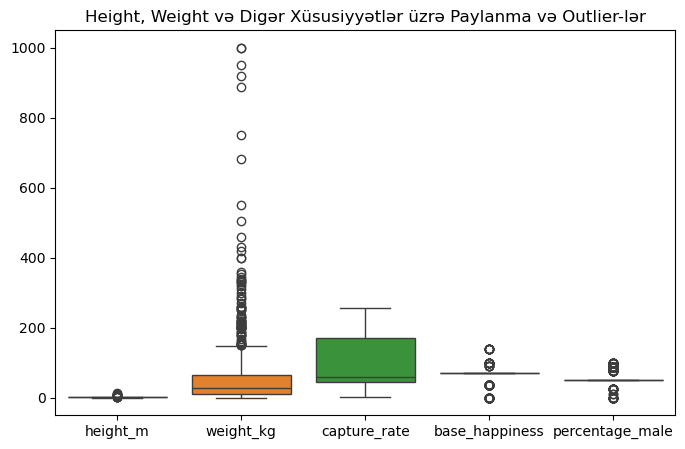

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['height_m','weight_kg','capture_rate','base_happiness','percentage_male']])

plt.title('Height, Weight və Digər Xüsusiyyətlər üzrə Paylanma və Outlier-lər')
plt.show()

#### Pokemonun capture rate ilə onun base total arasında əlaqə varmı? Bəs onun nadirliyi (legendary və ya deyil)?

In [10]:
df['capture_rate'].corr(df['base_total'])

np.float64(-0.7121201962428769)

In [11]:
df['capture_rate'].corr(df['is_legendary'])

np.float64(-0.3282121307256086)

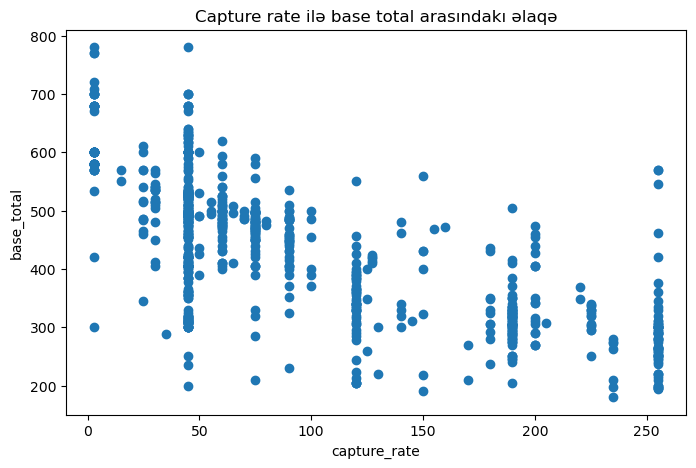

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df['capture_rate'],df['base_total'])
plt.title('Capture rate ilə base total arasındakı əlaqə')
plt.xlabel('capture_rate')
plt.ylabel('base_total')
plt.show()

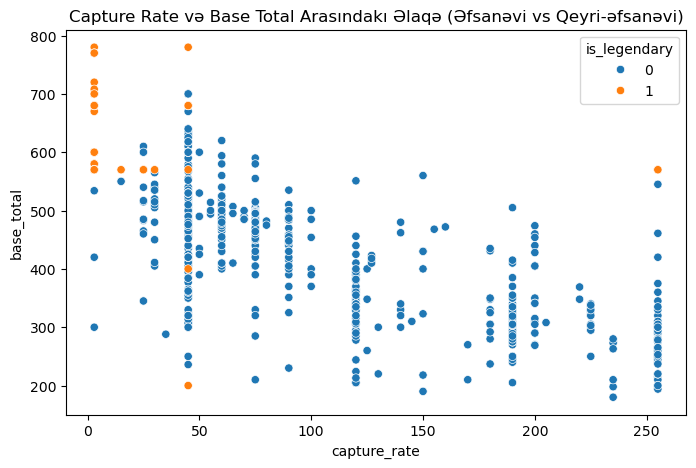

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='capture_rate',y='base_total', hue='is_legendary')
plt.title('Capture Rate və Base Total Arasındakı Əlaqə (Əfsanəvi vs Qeyri-əfsanəvi)')
plt.show()

#### Hansı Pokemon ən yüksək hücum statistikasına malikdir?

In [61]:
df[['name','attack']].sort_values(by='attack', ascending=False).head(1)

,name,attack
213,Heracross,185


#### Base total ilə HP, Attack, Defense, Special Attack, Special Defense və Speed kimi digər atributların hər biri arasında correlation nədir?

In [15]:
attribute = ['base_total','hp','attack','defense','sp_attack','sp_defense','speed','height_m','weight_kg',
             'is_legendary','generation','capture_rate','base_happiness','percentage_male']
df[attribute].corr()['base_total']

base_total         1.000000
hp                 0.621062
attack             0.729998
defense            0.630151
sp_attack          0.740986
sp_defense         0.717958
speed              0.547575
height_m           0.536017
weight_kg          0.458376
is_legendary       0.485811
generation         0.083241
capture_rate      -0.712120
base_happiness    -0.275044
percentage_male    0.098462
Name: base_total, dtype: float64

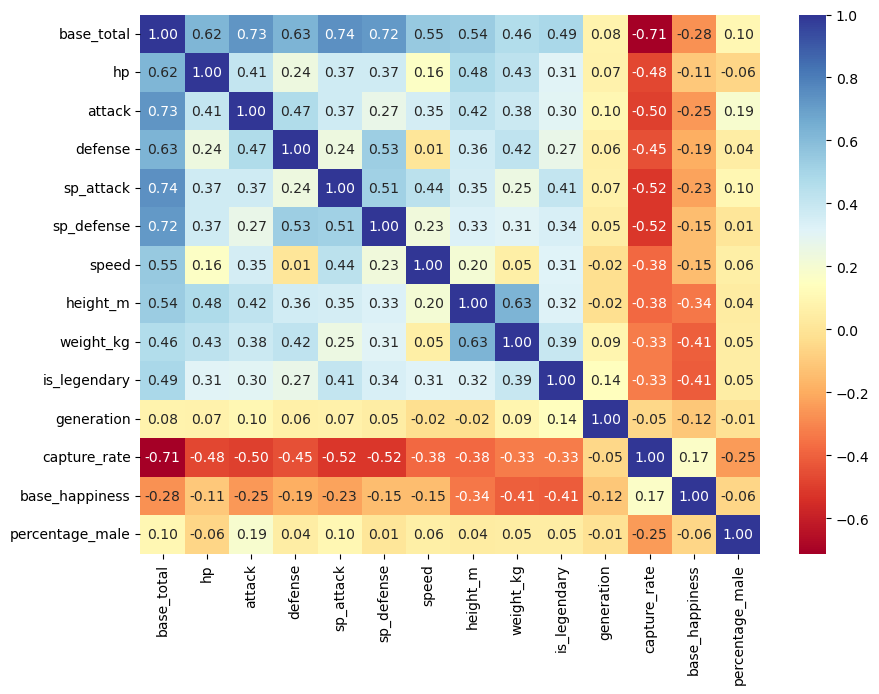

In [16]:
plt.figure(figsize=(10,7))
sns.heatmap(df[attribute].corr(),annot = True,cmap='RdYlBu',fmt='.2f')
plt.show()

#### Əfsanəvi və əfsanəvi olmayan Pokemonun ortalama hücum  arasında əhəmiyyətli fərq varmı?

In [76]:
mean =df.groupby('is_legendary')['attack'].mean()
print(mean)
legendary_attack=df[df['is_legendary'] == 1]['attack'].mean()
non_legendary_attack=df[df['is_legendary'] == 0]['attack'].mean()
print('Fərq:',legendary_attack-non_legendary_attack)

is_legendary
0     74.806849
1    109.357143
Name: attack, dtype: float64
Fərq: 34.55029354207437


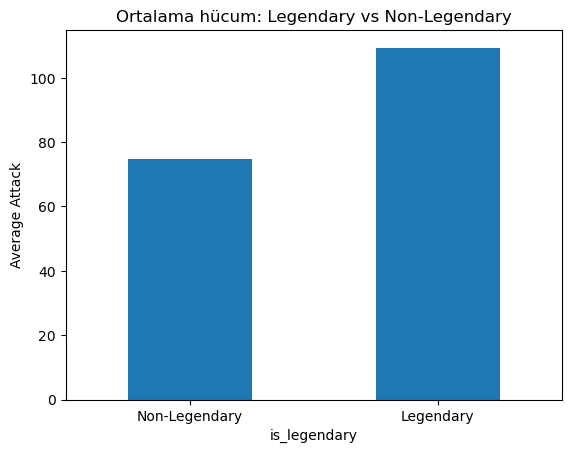

In [34]:
mean.plot(kind='bar')
plt.xticks([0,1], ['Non-Legendary', 'Legendary'], rotation=0)
plt.ylabel('Average Attack')
plt.title('Ortalama hücum: Legendary vs Non-Legendary')

plt.show()

#### Hansı tip 1 və tip 2 kombinasiyaları Pokemonlar arasında ən çox yayılmışdır?

In [74]:
df.groupby(['type1','type2']).size().sort_values(ascending=False).head(1)

type1   type2 
normal  flying    26
dtype: int64

#### Pokemonun çəkisi və boyu arasında korrelyasiya varmı?¶

In [31]:
df['weight_kg'].corr(df['height_m'])

np.float64(0.6266230704400672)

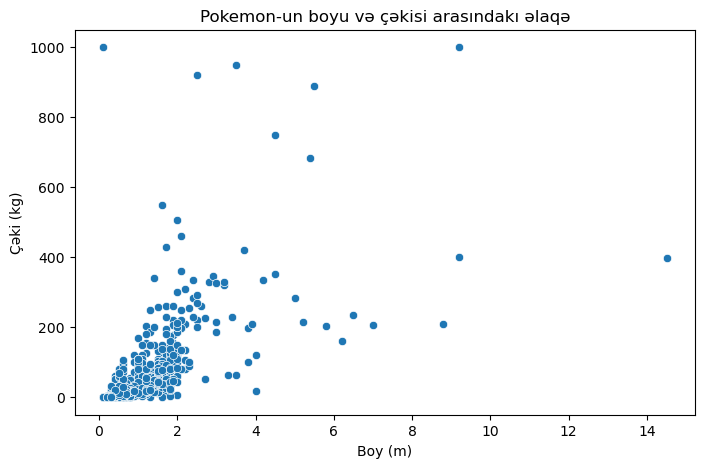

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='height_m', y='weight_kg')
plt.title('Pokemon-un boyu və çəkisi arasındakı əlaqə')
plt.xlabel('Boy (m)')
plt.ylabel('Çəki (kg)')
plt.show()

#### Hansı nəsil (generation) ən yüksək ortalama sürətə malikdir?

In [33]:
df.groupby('generation')['speed'].mean().sort_values(ascending=False).head(1)

generation
1    70.152318
Name: speed, dtype: float64

C:\Users\Lenova\AppData\Local\Temp\ipykernel_7516\327748916.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df,x='generation', y='speed',ci=False)


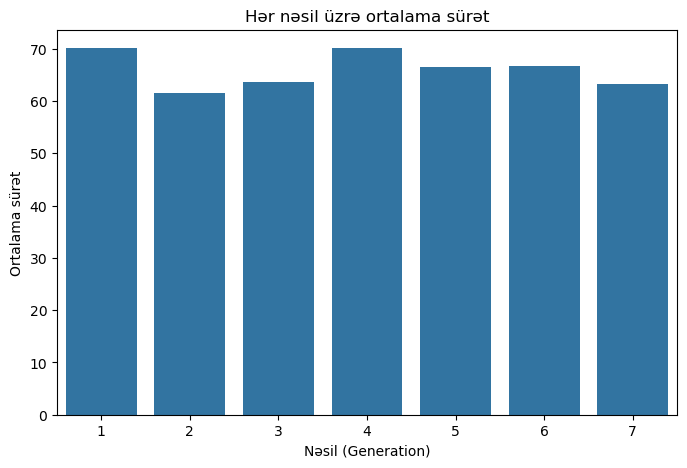

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='generation', y='speed',ci=False)
plt.title('Hər nəsil üzrə ortalama sürət')
plt.xlabel('Nəsil (Generation)')
plt.ylabel('Ortalama sürət')
plt.show()

#### Base total paylanması əfsanəvi və əfsanəvi olmayan Pokemon arasında necə dəyişir?

In [41]:
df.groupby('is_legendary')['base_total'].mean()

is_legendary
0    410.358904
1    615.257143
Name: base_total, dtype: float64

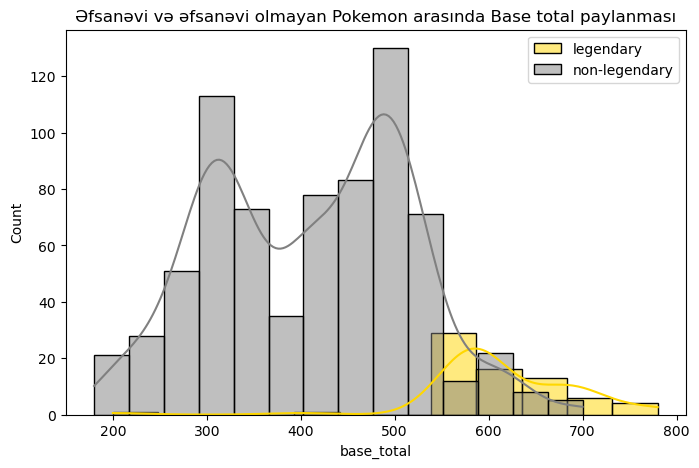

In [84]:
legendary_base = df[df['is_legendary']==1]['base_total']
non_legendary_base = df[df['is_legendary']==0]['base_total']

plt.figure(figsize=(8,5))
sns.histplot(legendary_base, color='gold', label='legendary', kde=True)
sns.histplot(non_legendary_base, color='grey', label='non-legendary', kde=True)
plt.title('Əfsanəvi və əfsanəvi olmayan Pokemon arasında Base total paylanması')
plt.legend()
plt.show()

#### Müxtəlif Pokemon tipləri arasında Defense paylanmasında əhəmiyyətli fərq varmı?

In [125]:
df.groupby('type1')['defense'].mean().sort_values(ascending= False)

type1
steel       120.208333
rock         97.090909
dragon       86.259259
ground       83.906250
ghost        79.518519
water        73.482456
ice          71.913043
grass        70.871795
bug          70.847222
dark         70.517241
poison       70.031250
psychic      69.264151
fairy        68.166667
fire         67.788462
fighting     66.392857
flying       65.000000
electric     61.820513
normal       59.695238
Name: defense, dtype: float64

C:\Users\Lenova\AppData\Local\Temp\ipykernel_7516\2017329364.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='type1',y='defense',palette='Set2')


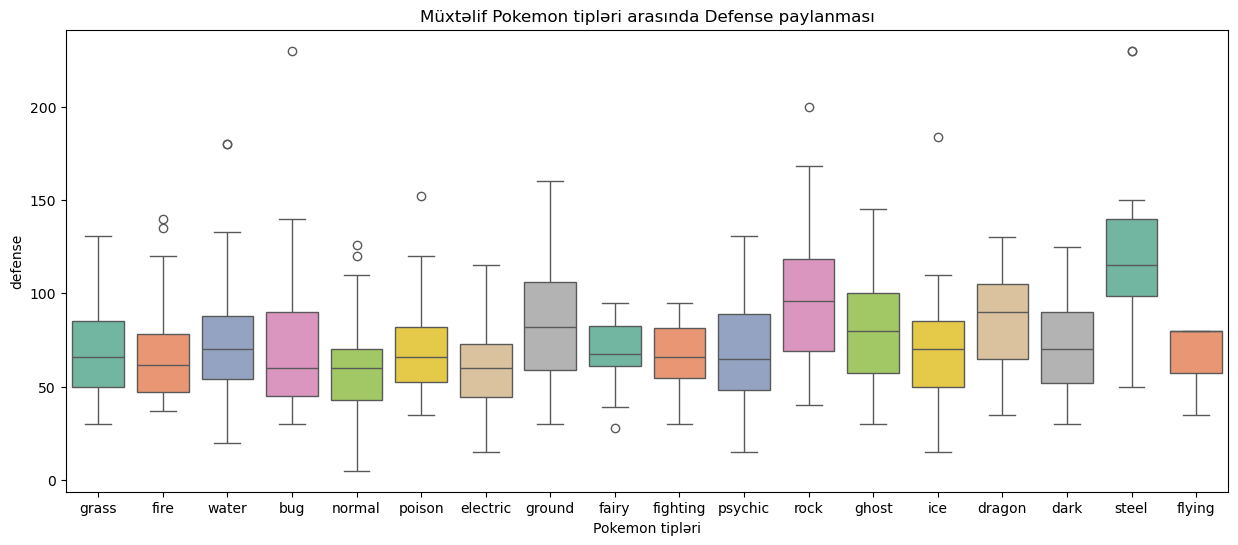

In [25]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='type1',y='defense',palette='Set2')
plt.title('Müxtəlif Pokemon tipləri arasında Defense paylanması')
plt.xlabel('Pokemon tipləri')
plt.show()

#### Pokemonun adını input kimi qəbul edən və onun statistikalarının olduğu lüğətini qaytaran funksiya yazın.

In [31]:
def pokemon(name):
    data_name = df[df['name'].str.lower() == name.lower()]
    
    if data_name.empty:
        return f"{name} adlı Pokémon tapılmadı."
    else:
        return data_name.iloc[0].to_dict()

pokemon_name = input('Pokemon adını daxil edin:')
stats = pokemon(pokemon_name)
print(stats)    

Pokemon adını daxil edin: Staryu


{'#': 120, 'name': 'Staryu', 'type1': 'water', 'type2': nan, 'base_total': 340, 'hp': 30, 'attack': 45, 'defense': 55, 'sp_attack': 70, 'sp_defense': 55, 'speed': 85, 'height_m': 0.8, 'weight_kg': 34.5, 'is_legendary': 0, 'generation': 1, 'capture_rate': 225, 'base_happiness': 70, 'percentage_male': nan}


#### Percentage_male sütununda boş dəyərləri öz tipinin ortalaması ilə doldurun

In [47]:
df[df['percentage_male'].isna()]

,#,name,type1,type2,base_total,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,is_legendary,generation,capture_rate,base_happiness,percentage_male
80,81,Magnemite,electric,steel,325,25,35,70,95,55,45,0.3,6.0,0,1,190,70,NaN
81,82,Magneton,electric,steel,465,50,60,95,120,70,70,1.0,60.0,0,1,60,70,NaN
99,100,Voltorb,electric,NaN,330,40,30,50,55,55,100,0.5,10.4,0,1,190,70,NaN
100,101,Electrode,electric,NaN,490,60,50,70,80,80,150,1.2,66.6,0,1,60,70,NaN
119,120,Staryu,water,NaN,340,30,45,55,70,55,85,0.8,34.5,0,1,225,70,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Celesteela,steel,flying,570,97,101,103,107,101,61,9.2,999.9,1,7,25,0,NaN
796,797,Kartana,grass,steel,570,59,181,131,59,31,109,0.3,0.1,1,7,255,0,NaN
797,798,Guzzlord,dark,dragon,570,223,101,53,97,53,43,5.5,888.0,1,7,15,0,NaN
798,799,Necrozma,psychic,NaN,600,97,107,101,127,89,79,2.4,230.0,1,7,3,0,NaN


In [48]:
df['percentage_male'] = df['percentage_male'].fillna( df.groupby('type1')['percentage_male'].transform('mean'))

In [49]:
df[df['percentage_male'].isna()]

,#,name,type1,type2,base_total,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,is_legendary,generation,capture_rate,base_happiness,percentage_male


#### Daha çox kişiyə yaxın olan pokemonlar daha güclüdür, yoxsa qadına yaxın olanlar?

In [92]:
def güc(x):
    if x > 50:
        return 'kişiyə yaxın olan pokemon'
    else:
        return 'qadına yaxın olan pokemon'

df['gender_group'] = df['percentage_male'].apply(güc)

group_mean = df.groupby('gender_group')['base_total'].mean()
print(group_mean)

if group_mean['kişiyə yaxın olan pokemon'] > group_mean['qadına yaxın olan pokemon']:
     print('Kişiyə yaxın olan pokemonlar daha güclüdür')
else:
    print('Qadına yaxın olan pokemonlar daha güclüdür')

gender_group
kişiyə yaxın olan pokemon    437.919463
qadına yaxın olan pokemon    426.082949
Name: base_total, dtype: float64
Kişiyə yaxın olan pokemonlar daha güclüdür


#### Əfsanəvi və ya əfsanəvi olmayan pokemonların ortalama çəkiləri və boyları arasında önəmli bir fərq var?

In [51]:
df.groupby('is_legendary')[['weight_kg','height_m']].mean()

,weight_kg,height_m
is_legendary,,
0,48.018425,1.056681
1,199.350725,2.281159


In [118]:
legendary=df[df['is_legendary'] == 1]
non_legendary=df[df['is_legendary'] == 0]

print('Əfsanəvi Pokemonlar ortalama:')
print(legendary[['height_m','weight_kg']].mean())

print('\nƏfsanəvi olmayan Pokemonlar ortalama:')
print(non_legendary[['height_m','weight_kg']].mean())

print('\nboy fərqi:',legendary['height_m'].mean()-non_legendary['height_m'].mean())
print('çəki fərqi:',legendary['weight_kg'].mean()-non_legendary['weight_kg'].mean())

Əfsanəvi Pokemonlar ortalama:
height_m       2.281159
weight_kg    199.350725
dtype: float64

Əfsanəvi olmayan Pokemonlar ortalama:
height_m      1.056681
weight_kg    48.018425
dtype: float64

boy fərqi: 1.2244786889255794
çəki fərqi: 151.33229988381333


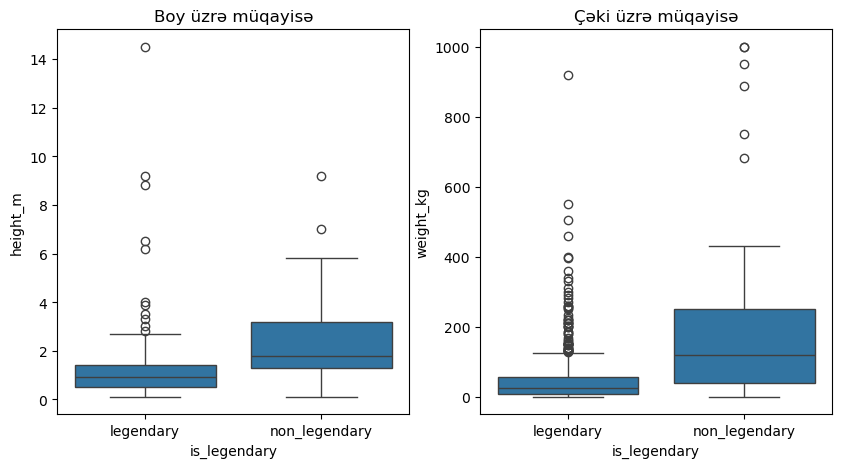

In [122]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(data=df,x='is_legendary',y='height_m')
plt.xticks([0,1],['legendary','non_legendary'])
plt.title('Boy üzrə müqayisə')

plt.subplot(1,2,2)
sns.boxplot(data=df,x='is_legendary',y='weight_kg')
plt.xticks([0,1],['legendary','non_legendary'])
plt.title('Çəki üzrə müqayisə')

plt.show()

#### Hansı tip1 və tip2 kombinasiyası daha xoşbəxtdir?

In [28]:
df.groupby(['type1','type2'])['base_happiness'].sum().sort_values(ascending=False).head(1)

type1   type2 
normal  flying    1785
Name: base_happiness, dtype: int64

#### Tiplər üzrə ortalama çəki və boyları tapın

In [53]:
df.groupby(['type1','type2'])[['weight_kg','height_m']].mean()

weight_kg  height_m
type1 type2                         
bug   electric   17.600000     0.725
      fairy       0.350000     0.150
      fighting  137.533333     1.900
      fire       37.400000     1.350
      flying     27.092308     1.100
...                    ...       ...
water ice       157.500000     1.900
      poison     34.800000     1.000
      psychic    58.600000     1.360
      rock       31.475000     0.875
      steel      84.500000     1.700

[148 rows x 2 columns]

### Mən oynamaq üçün ən ideal pokemonu seçmək istəsəm, hansını seçməliyəm? Bunun üçün özünüzə uyğun xüsusi bir analiz aparın və seçdiyiniz pokemonu əsaslandırın

In [54]:
df['avg_stat'] = df[['hp','attack','defense','sp_attack','sp_defense','speed']].mean(axis=1)
df.sort_values(by='avg_stat', ascending=False)[['name','hp','attack','defense','sp_attack','sp_defense','speed']].head(1)

,name,hp,attack,defense,sp_attack,sp_defense,speed
149,Mewtwo,106,150,70,194,120,140


#### Bu analizdə hər bir Pokemonun əsas statistikasını (hp, attack, defense, sp_attack, sp_defense, speed) nəzərə aldım.Bu statistikalardan orta dəyər (avg_stat) hesabladım və ən yüksək olanları sıraladım.Nəticədə Mewtwo ən yüksək orta statistikaya sahib olduğu üçün ən ideal pokemon olaraq Mewtwo -nu seçirəm. 

#### Apardığınız analizlərin nəticəsinə uyğun olaraq vizuallaşdırmalar aparın və bir dashboard qurun

C:\Users\Lenova\AppData\Local\Temp\ipykernel_7516\4292369789.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='type1',y='defense',palette='Set2')


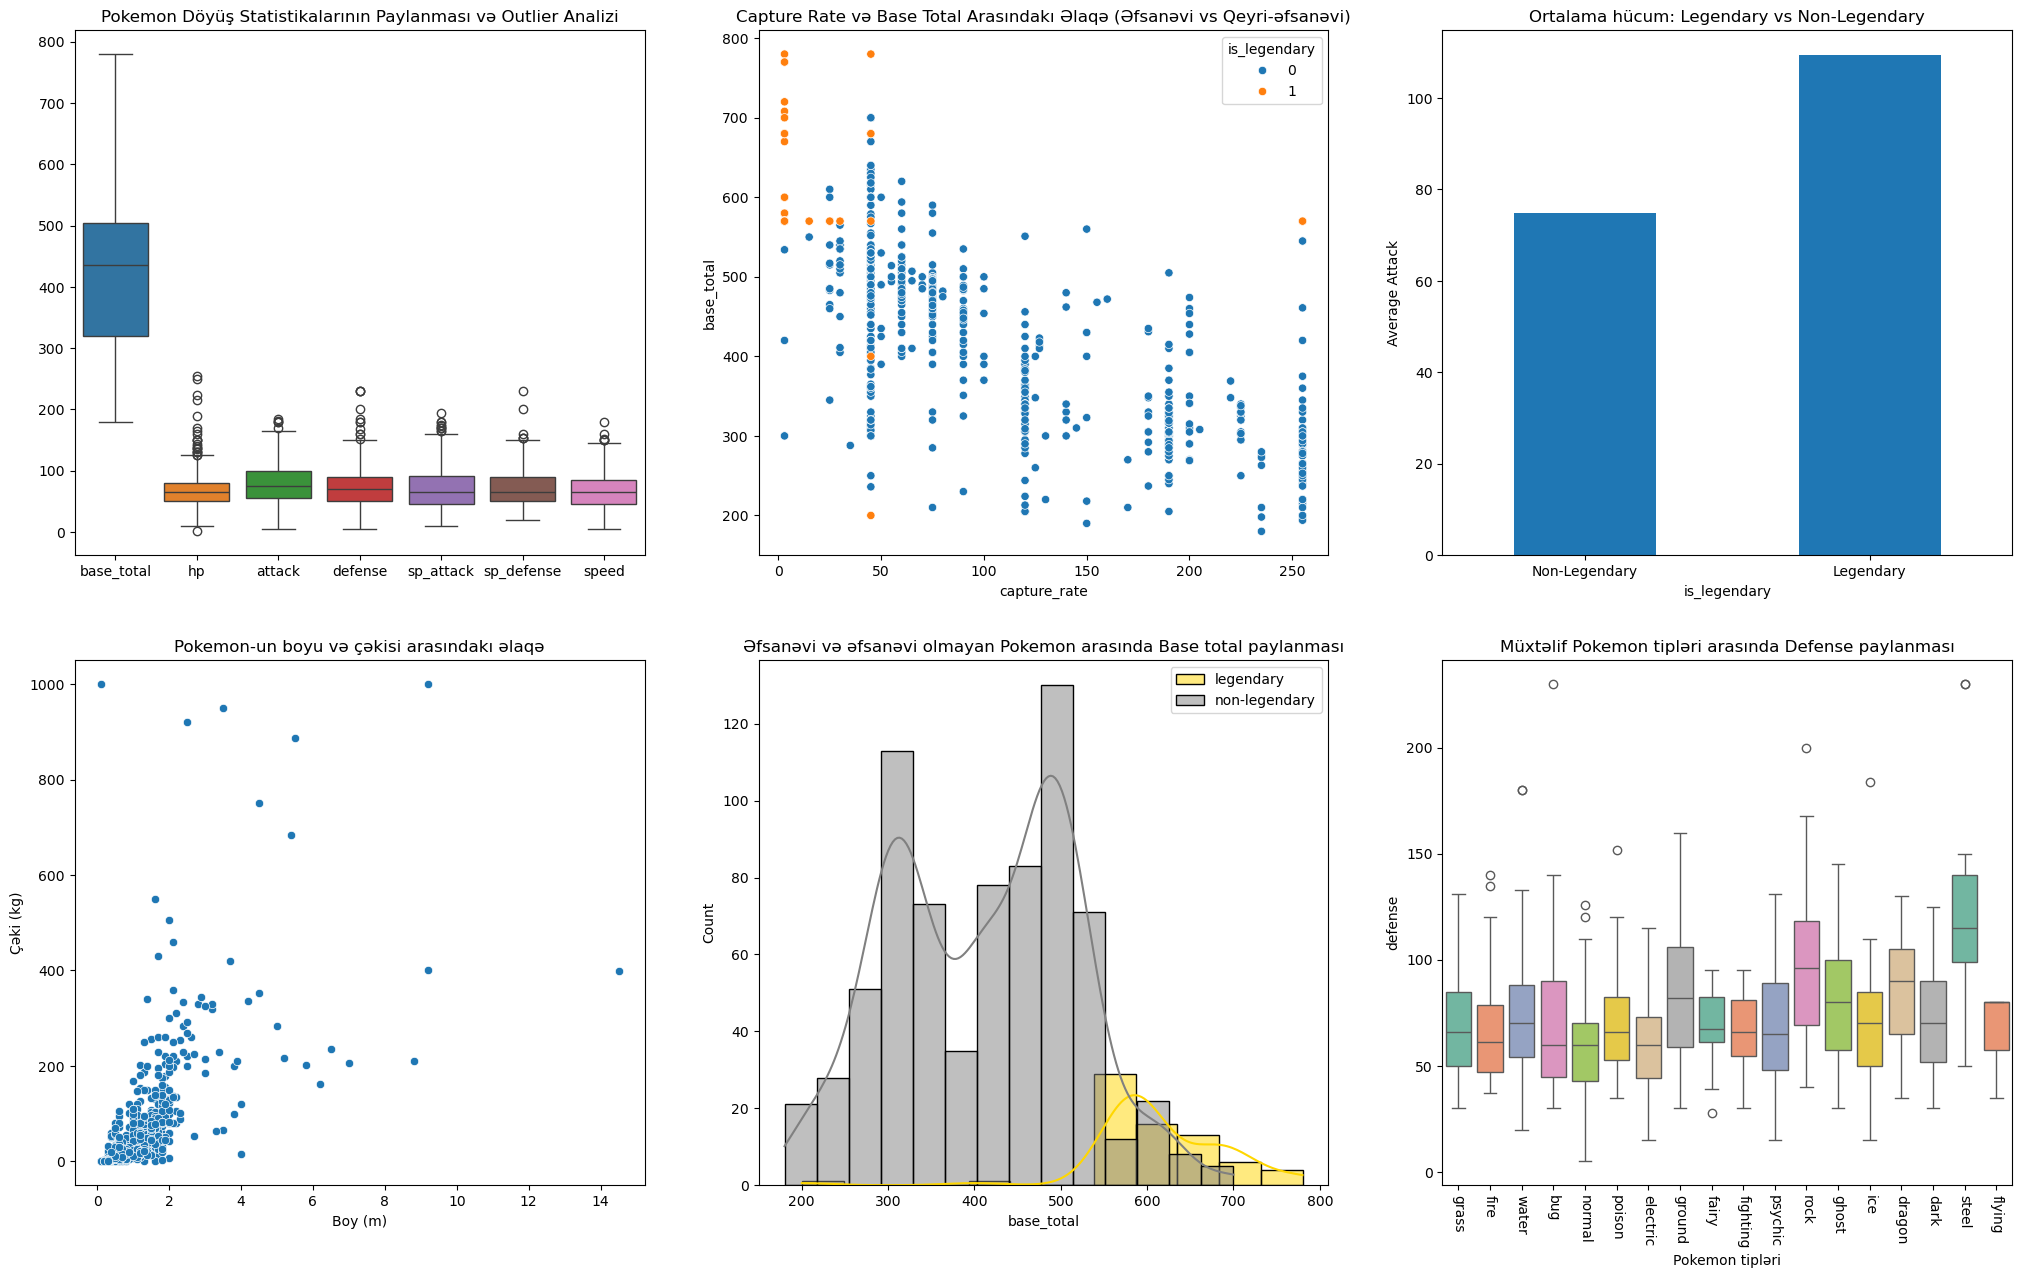

In [26]:
plt.figure(figsize=(25,15))
plt.subplot(2,3,1)
sns.boxplot(data=df[['base_total','hp','attack','defense','sp_attack','sp_defense','speed']])
plt.title('Pokemon Döyüş Statistikalarının Paylanması və Outlier Analizi')

plt.subplot(2,3,2)
sns.scatterplot(data=df,x='capture_rate',y='base_total', hue='is_legendary')
plt.title('Capture Rate və Base Total Arasındakı Əlaqə (Əfsanəvi vs Qeyri-əfsanəvi)')

plt.subplot(2,3,3)
mean =df.groupby('is_legendary')['attack'].mean()
legendary_attack=df[df['is_legendary'] == 1]['attack'].mean()
non_legendary_attack=df[df['is_legendary'] == 0]['attack'].mean()
mean.plot(kind='bar')
plt.xticks([0,1], ['Non-Legendary', 'Legendary'], rotation=0)
plt.ylabel('Average Attack')
plt.title('Ortalama hücum: Legendary vs Non-Legendary')

plt.subplot(2,3,4)
sns.scatterplot(data=df, x='height_m', y='weight_kg')
plt.title('Pokemon-un boyu və çəkisi arasındakı əlaqə')
plt.xlabel('Boy (m)')
plt.ylabel('Çəki (kg)')

plt.subplot(2,3,5)
legendary_base = df[df['is_legendary']==1]['base_total']
non_legendary_base = df[df['is_legendary']==0]['base_total']
sns.histplot(legendary_base, color='gold', label='legendary', kde=True)
sns.histplot(non_legendary_base, color='grey', label='non-legendary', kde=True)
plt.title('Əfsanəvi və əfsanəvi olmayan Pokemon arasında Base total paylanması')
plt.legend()

plt.subplot(2,3,6)
sns.boxplot(data=df,x='type1',y='defense',palette='Set2')
plt.title('Müxtəlif Pokemon tipləri arasında Defense paylanması')
plt.xlabel('Pokemon tipləri')
plt.xticks(rotation=270)

plt.show()